# Uplift Modeling for Retention Targeting

The first two notebooks answered "who's churning?" (`01_business_analysis.ipynb`) and "who will churn?" (`02_model_analysis.ipynb`). This one tackles the question a retention team actually asks:

> We have a fixed budget to run a retention campaign. Which customers should we call?

Risk ranking and targeting ranking aren't the same thing. A high-risk customer can be impossible to save (bad service experience, moved out of area, a competitor's price that nothing on offer matches). And a mid-risk customer with the right profile can be exactly who a small concession retains. Risk ranking optimizes for "who will leave." Uplift ranking optimizes for "who changes their mind *because of* the intervention." The second is what the budget is actually for.

## About the dataset — read before trusting anything below

This dataset has no treatment column. There's no `received_offer` flag, no A/B test history, nothing that actually experienced a retention intervention. Real uplift modeling needs `(features, treatment, outcome)` triples from a randomized experiment, and we don't have one.

So this notebook is a **methodology demonstration**. We synthesize both the treatment assignment and a plausible, feature-dependent treatment effect on top of the observed data, then run the uplift workflow end-to-end against that construction. Because we *defined* the true per-customer effect, we can score the uplift models against ground truth — a luxury we'd never have on real data.

The value sits in the structure: how to frame retention targeting as a treatment-effect problem, how to fit and evaluate uplift models, and what to compare them against. See `docs/data_card.md` for the dataset's broader limitations and `notebooks/02_model_analysis.ipynb` for the risk model this builds on.


In [1]:
# Notebook-only dep:  pip install causalml
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from xgboost import XGBClassifier, XGBRegressor

from causalml.inference.meta import BaseTClassifier, BaseXClassifier
from causalml.metrics import plot_qini, auuc_score

from src.data.load_data import load_data
from src.data.preprocess import preprocess_data
from src.features.build_features import build_features

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
RANDOM_STATE = 42
PRIMARY = '#4c8dae'
ACCENT = '#e07b6f'
NEUTRAL = '#888888'
np.random.seed(RANDOM_STATE)


In [2]:
df_raw = load_data('../data/raw/Customer-Churn.csv')
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce').fillna(0)

df_model = preprocess_data(df_raw.copy(), target_col='Churn')
df_enc = build_features(df_model, target_col='Churn')

X = df_enc.drop(columns=['Churn'])
y = df_enc['Churn'].astype(int)

scale_pos_weight = (y == 0).sum() / (y == 1).sum()

base_model = XGBClassifier(
    n_estimators=301,
    learning_rate=0.034,
    max_depth=7,
    subsample=0.95,
    colsample_bytree=0.98,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
p_base = cross_val_predict(base_model, X, y, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]

print(f'{len(p_base):,} customers scored out-of-fold.')
print(f'Predicted churn probability - mean {p_base.mean():.3f}, observed churn rate {y.mean():.3f}')


Starting feature engineering on 20 columns...
  Found 15 categorical and 5 numeric columns
Feature engineering complete: 31 final features


7,043 customers scored out-of-fold.
Predicted churn probability - mean 0.359, observed churn rate 0.265


## Simulating a retention experiment

We need two things the dataset can't give us: a treatment assignment `T` and a potential outcome under treatment, `Y(1)`. Both get synthesized.

**Treatment assignment.** Random 50/50, independent of features. In a real trial this is the control-vs-treated flag.

**Per-customer treatment effect τ(x).** Heterogeneous — some customers are more persuadable than others:

- **Month-to-month contract** → larger τ. Easy to leave, so a small concession meaningfully changes the decision.
- **High `MonthlyCharges`** → larger τ. Price-sensitive customers respond to discounts.
- **Medium tenure (12-36 months)** → larger τ. Long enough to have formed a habit, short enough not to be deeply locked in.
- **Two-year contract** → negative τ. Already committed; a retention offer here is wasted budget.
- **Very new customers (tenure < 3)** → small negative τ. They haven't really decided yet; an early call can signal desperation.

We simulate `Y(1)` via a flip rule applied to each customer's observed churn label `Y(0)`:

```
Y(0, X) = observed churn label from the dataset
If τ(X) > 0: with probability τ(X), flip Y(1) from 1 → 0 when Y(0) = 1  (a would-be churner is saved)
If τ(X) < 0: with probability |τ(X)|, flip Y(1) from 0 → 1 when Y(0) = 0 (a would-be stayer is lost)
Otherwise, Y(1) = Y(0).
```

Control keeps its observed outcome; treated gets `Y(1)`. Two things to note. First, τ(x) here is the *conditional* flip probability, not the unconditional treatment effect — the unconditional uplift on retention works out to roughly `τ(x) × P(churn | x)` for persuadable customers. Second, this flip coupling is deliberately simple. A production-grade simulation would add noise, interactions, and feature-dependent baselines; the goal here is a clear, recoverable signal for the uplift models to find.


Treated:  3,636 (51.6%)
Control:  3,407 (48.4%)

Churn rate - control 0.266, treated 0.220
Observed lift (control - treated): +0.046
True τ(x)  - mean +0.183, range [-0.300, +0.500]
Simulated individual effect counts: saves 599, harms 246


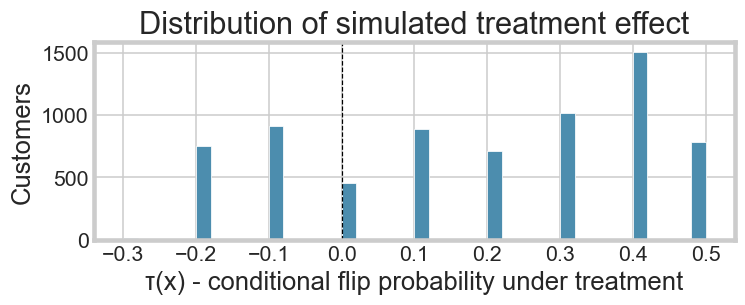

In [3]:
def simulate_tau(raw):
    tau = np.zeros(len(raw))
    tau += 0.30 * (raw['Contract'] == 'Month-to-month').values
    tau += 0.10 * (raw['MonthlyCharges'] > raw['MonthlyCharges'].median()).values
    tau += 0.10 * ((raw['tenure'] >= 12) & (raw['tenure'] <= 36)).values
    tau -= 0.20 * (raw['Contract'] == 'Two year').values
    tau -= 0.10 * (raw['tenure'] < 3).values
    return np.clip(tau, -1.0, 1.0)

tau_true = simulate_tau(df_raw)

rng = np.random.RandomState(RANDOM_STATE + 1)
T = rng.binomial(1, 0.5, size=len(df_raw))

y0 = y.values.astype(int)
y1 = y0.copy()

tau_pos = np.clip(tau_true, 0.0, 1.0)
tau_neg = -np.clip(tau_true, -1.0, 0.0)
save_mask = (y0 == 1) & (rng.uniform(size=len(y0)) < tau_pos)
harm_mask = (y0 == 0) & (rng.uniform(size=len(y0)) < tau_neg)
y1[save_mask] = 0
y1[harm_mask] = 1

y_obs_churn = np.where(T == 1, y1, y0)
y_obs_retained = 1 - y_obs_churn

print(f'Treated:  {T.sum():,} ({T.mean():.1%})')
print(f'Control:  {(1 - T).sum():,} ({(1 - T.mean()):.1%})')
print()
print(f'Churn rate - control {y_obs_churn[T == 0].mean():.3f}, treated {y_obs_churn[T == 1].mean():.3f}')
print(f'Observed lift (control - treated): {y_obs_churn[T == 0].mean() - y_obs_churn[T == 1].mean():+.3f}')
print(f'True τ(x)  - mean {tau_true.mean():+.3f}, range [{tau_true.min():+.3f}, {tau_true.max():+.3f}]')
print(f'Simulated individual effect counts: saves {save_mask.sum():,}, harms {harm_mask.sum():,}')

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(tau_true, bins=40, color=PRIMARY, edgecolor='white')
ax.axvline(0, color='k', lw=0.8, linestyle='--')
ax.set_xlabel('τ(x) - conditional flip probability under treatment')
ax.set_ylabel('Customers')
ax.set_title('Distribution of simulated treatment effect')
plt.tight_layout()
plt.show()


## Meta-learner patterns (and why we pick two)

Uplift meta-learners reuse any standard classifier under the hood and differ in how they stitch treatment / control information together:

- **S-learner** — one model with treatment as just another feature. Simple, but biased toward a zero estimate when the treatment signal is weak next to everything else.
- **T-learner** — two models, one per arm. Take the difference of their predictions. Reasonable when the data is balanced; over-fits the smaller arm otherwise.
- **X-learner** — a two-stage refinement. Fit outcome models per arm, impute counterfactuals, fit a second-stage effect model on the residuals, and blend via propensity. Built to handle imbalance and small-sample arms.

We fit T- and X-learners below. Skipping the S-learner and a causal-forest baseline keeps the comparison focused — same reason we don't swap in `econml`. On a real project both would probably be in the pack.

One implementation note: we model the outcome as `y_retained = 1 - y_churn` so that higher predicted uplift reads in the natural "more persuadable toward staying" direction, and the Qini tooling works without sign gymnastics.


In [4]:
X_arr = X.values
idx_all = np.arange(len(X_arr))
idx_train, idx_test = train_test_split(
    idx_all, test_size=0.3, random_state=RANDOM_STATE, stratify=T,
)

X_train, X_test = X_arr[idx_train], X_arr[idx_test]
T_train, T_test = T[idx_train], T[idx_test]
y_train, y_test = y_obs_retained[idx_train], y_obs_retained[idx_test]
tau_train, tau_test = tau_true[idx_train], tau_true[idx_test]
p_base_test = p_base[idx_test]
y_churn_test = y_obs_churn[idx_test]

t_learner = BaseTClassifier(
    learner=XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        eval_metric='logloss', n_jobs=-1, random_state=RANDOM_STATE,
    )
)
t_learner.fit(X=X_train, treatment=T_train, y=y_train)
uplift_t = t_learner.predict(X_test).flatten()

print(f'T-learner predicted uplift - mean {uplift_t.mean():+.4f}, std {uplift_t.std():.4f}')
print(f'Correlation with true τ on test set: {np.corrcoef(uplift_t, tau_test)[0, 1]:+.3f}')


T-learner predicted uplift - mean +0.0333, std 0.1747
Correlation with true τ on test set: +0.655


X-learner predicted uplift - mean +0.0348, std 0.1305
Correlation with true τ on test set: +0.814


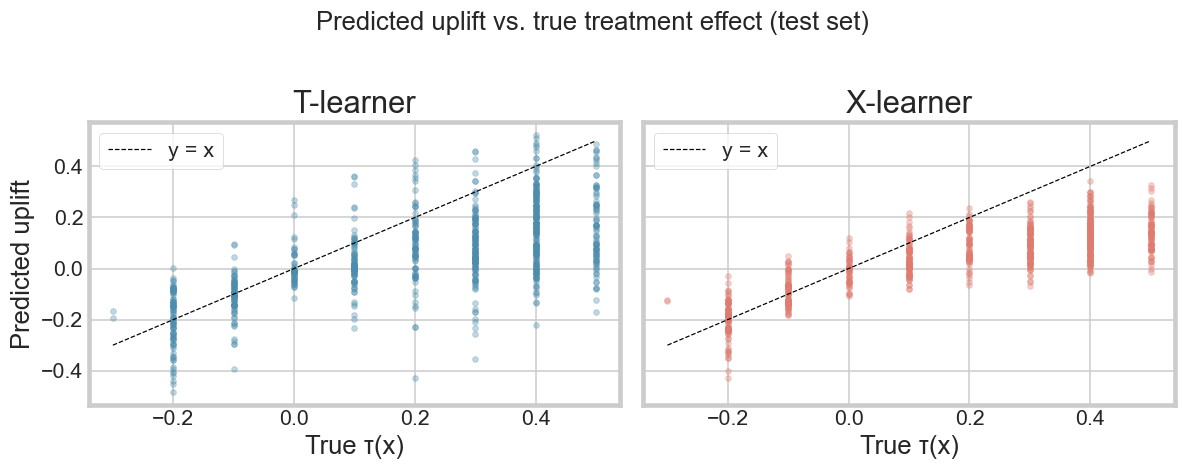

In [5]:
x_learner = BaseXClassifier(
    outcome_learner=XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        eval_metric='logloss', n_jobs=-1, random_state=RANDOM_STATE,
    ),
    effect_learner=XGBRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        n_jobs=-1, random_state=RANDOM_STATE,
    ),
)
x_learner.fit(X=X_train, treatment=T_train, y=y_train)
uplift_x = x_learner.predict(X_test, verbose=False).flatten()

print(f'X-learner predicted uplift - mean {uplift_x.mean():+.4f}, std {uplift_x.std():.4f}')
print(f'Correlation with true τ on test set: {np.corrcoef(uplift_x, tau_test)[0, 1]:+.3f}')

sample = np.random.RandomState(RANDOM_STATE).choice(len(tau_test), size=min(800, len(tau_test)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True, sharey=True)
for ax, uplift, name, color in [
    (axes[0], uplift_t, 'T-learner', PRIMARY),
    (axes[1], uplift_x, 'X-learner', ACCENT),
]:
    ax.scatter(tau_test[sample], uplift[sample], alpha=0.35, s=14, color=color)
    lo, hi = tau_test.min(), tau_test.max()
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, label='y = x')
    ax.set_xlabel('True τ(x)')
    ax.set_title(name)
    ax.legend(loc='upper left')
axes[0].set_ylabel('Predicted uplift')
plt.suptitle('Predicted uplift vs. true treatment effect (test set)', y=1.02)
plt.tight_layout()
plt.show()


## How good are the uplift models?

Four views, each answering a slightly different question.

1. **Uplift by decile.** Sort test-set customers by predicted uplift, bucket into ten, then look at the mean *true* τ in each bucket. A useful model puts the most persuadable customers in the top deciles and the lost-cause / negative-effect customers at the bottom.

2. **Qini curve.** As we target more customers (ranked by predicted uplift), how many of the "reachable" saves do we accumulate relative to random targeting? The larger the area between the curve and the random line, the better.

3. **AUUC.** Area under the uplift curve. Same idea as Qini, different normalization.

4. **Versus baselines.** The real comparison isn't "T-learner vs. X-learner," it's "either uplift model vs. the alternatives someone actually uses." We include two: **risk-based** targeting (rank by predicted churn probability, the implicit recommendation from notebook 02) and **random.** The interesting result, if the uplift approach works, is that it beats risk-based at finding the most persuadable customers — not just the most at-risk ones.


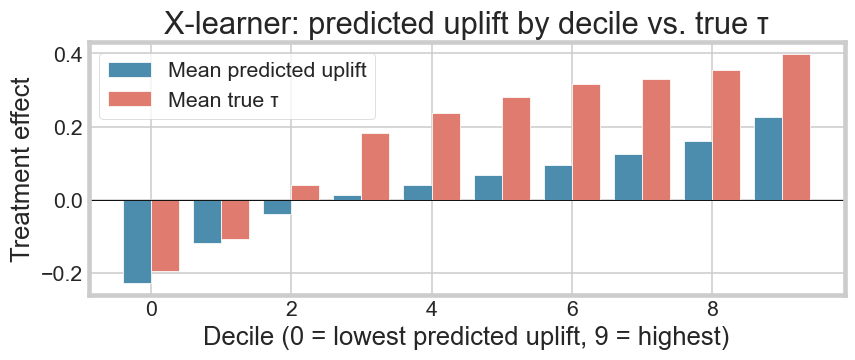

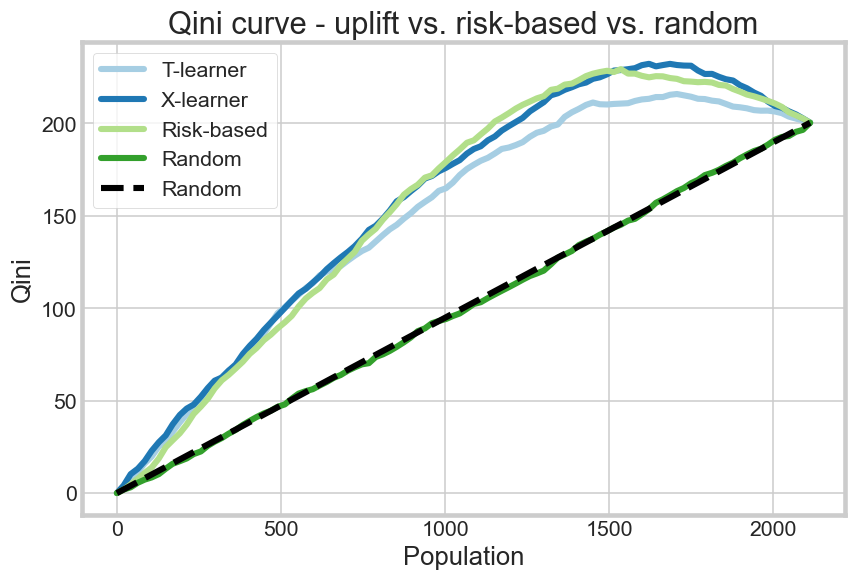

AUUC (normalized - 1.0 = perfect model, 0.5 ≈ random):
T-learner     0.748
X-learner     0.787
Risk-based    0.775
Random        0.500


In [6]:
# Decile chart (X-learner)
decile_df = pd.DataFrame({'predicted_uplift': uplift_x, 'true_tau': tau_test})
decile_df['decile'] = pd.qcut(decile_df['predicted_uplift'], 10, labels=False, duplicates='drop')
decile_summary = decile_df.groupby('decile').agg(
    mean_predicted=('predicted_uplift', 'mean'),
    mean_true=('true_tau', 'mean'),
).reset_index()

fig, ax = plt.subplots(figsize=(8, 3.5))
width = 0.4
idx_d = decile_summary['decile']
ax.bar(idx_d - width/2, decile_summary['mean_predicted'], width, label='Mean predicted uplift', color=PRIMARY)
ax.bar(idx_d + width/2, decile_summary['mean_true'], width, label='Mean true τ', color=ACCENT)
ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('Decile (0 = lowest predicted uplift, 9 = highest)')
ax.set_ylabel('Treatment effect')
ax.set_title('X-learner: predicted uplift by decile vs. true τ')
ax.legend()
plt.tight_layout()
plt.show()

# Qini + AUUC comparison
random_score = np.random.RandomState(RANDOM_STATE).uniform(size=len(idx_test))

eval_df = pd.DataFrame({
    'y': y_test,
    'w': T_test,
    'tau': tau_test,
    'T-learner': uplift_t,
    'X-learner': uplift_x,
    'Risk-based': p_base_test,
    'Random': random_score,
})

fig, ax = plt.subplots(figsize=(8, 5.5))
plot_qini(eval_df, outcome_col='y', treatment_col='w', treatment_effect_col='tau', n=100, ax=ax)
ax.set_title('Qini curve - uplift vs. risk-based vs. random')
plt.tight_layout()
plt.show()

auuc = auuc_score(eval_df, outcome_col='y', treatment_col='w', treatment_effect_col='tau', normalize=True)
print('AUUC (normalized - 1.0 = perfect model, 0.5 ≈ random):')
print(auuc.round(3).to_string())


## The budget question

Assume the retention team can call **500 customers** out of the ~2,100 in the test set. Three strategies to pick those 500:

- **Random** — no model, no ranking. Baseline for "do nothing smart."
- **Risk-based** — rank by predicted churn probability; take the 500 highest-risk. The implicit recommendation from notebook 02.
- **Uplift-based** — rank by predicted uplift from the X-learner; take the 500 most persuadable.

We score each strategy by summing the true τ for the customers it picks — the expected per-customer churn-probability reduction, aggregated. Under the simulated effect, the uplift strategy should win by a clear margin: some of the highest-risk customers are lost causes, and some highly persuadable customers sit at moderate risk. Risk-based targeting captures neither insight.


          Strategy  Targeted  Expected saves (sum τ)  vs. random
            Random       500                    91.3        1.00
        Risk-based       500                   183.6        2.01
Uplift (X-learner)       500                   186.5        2.04


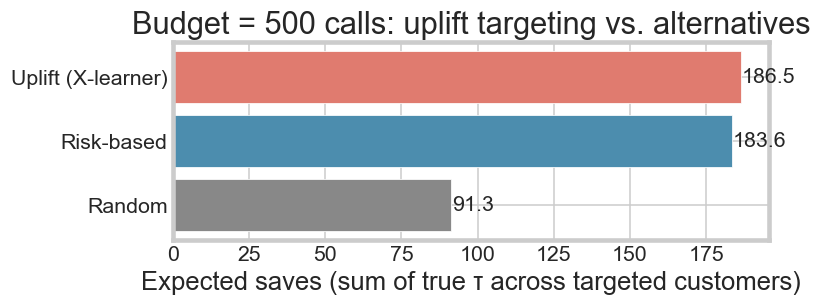

In [7]:
BUDGET = 500

strategies = {
    'Random':              np.random.RandomState(RANDOM_STATE).uniform(size=len(tau_test)),
    'Risk-based':          p_base_test,
    'Uplift (X-learner)':  uplift_x,
}

rows = []
for name, score in strategies.items():
    top_k = np.argsort(-score)[:BUDGET]
    expected_saves = tau_test[top_k].sum()
    rows.append({'Strategy': name, 'Targeted': BUDGET, 'Expected saves (sum τ)': expected_saves})

budget_df = pd.DataFrame(rows)
baseline = budget_df.loc[budget_df['Strategy'] == 'Random', 'Expected saves (sum τ)'].iloc[0]
budget_df['vs. random'] = (budget_df['Expected saves (sum τ)'] / baseline).round(2)
budget_df['Expected saves (sum τ)'] = budget_df['Expected saves (sum τ)'].round(2)

print(budget_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7.5, 3))
colors = [NEUTRAL, PRIMARY, ACCENT]
ax.barh(budget_df['Strategy'], budget_df['Expected saves (sum τ)'], color=colors)
ax.set_xlabel('Expected saves (sum of true τ across targeted customers)')
ax.set_title(f'Budget = {BUDGET} calls: uplift targeting vs. alternatives')
for i, v in enumerate(budget_df['Expected saves (sum τ)']):
    ax.text(v + 0.3, i, f'{v:.1f}', va='center')
plt.tight_layout()
plt.show()


## What would change on real data

Running the same workflow on a live operator's data would need several things this notebook glosses over:

- **A real randomized experiment.** You can't synthesize τ when dollars and customers are real. Designing the retention-offer A/B test — no-offer holdout, power calculation, stratification, offer definition — is half the actual work.
- **Compliance and finance review.** Randomizing retention offers on paying customers pulls legal, finance, and retention-ops into the loop. None of them move at the speed a DS team wants.
- **Propensity modeling.** If assignment isn't clean 50/50 (because legacy campaigns already ran, or the experiment had targeting constraints), uplift estimators need a propensity score. `causalml`'s X-learner accepts `p=` for exactly this.
- **Sensitivity analysis.** Real uplift work lives in "who is the effect actually for?" — by segment, by product, by acquisition channel. One number averaged across the whole base hides the decisions that matter.
- **Policy, not just model.** The output is a targeting policy, not a scored customer list. Real teams iterate: experiment → uplift model → policy → next experiment, each cycle tightening the targeting.

The methodology in this notebook transfers to that world. The dollar figures and the specific τ distribution absolutely do not.


## Descriptive → predictive → prescriptive

These three notebooks form the decision stack a growth or retention team actually runs against:

- `01_business_analysis.ipynb` — **descriptive.** Who's churning, which segments, what's the revenue exposure? (DA framing.)
- `02_model_analysis.ipynb` — **predictive.** Given what we know about a customer today, how likely are they to churn? (DS framing.)
- `03_uplift_modeling.ipynb` — **prescriptive.** Of the customers we could target, who's actually persuadable by an intervention? (GTM DS framing.)

The predictive model tells you the *risk*. The uplift model tells you the *ROI of intervention*. They answer different questions. Targeting everyone the risk model flags wastes budget on lost causes and misses the persuadable mid-risk customers who'd have stayed if someone called. That's the part of the story a predictive-only workflow can't tell.
